In [2]:
# ============================================================
# Heart Disease Prediction — Exploratory Data Analysis (EDA)
# ============================================================
# Sprint 1 / Notebook 01
# Yazarlar: Alperen ARSLAN, Alper Kaan ŞAHBAZ
# Amaç: Heart Disease dataset'ini keşfetmek, dağılımları
#       anlamak ve modelleme stratejisi için içgörü çıkarmak.
# ============================================================

# Standart kütüphaneler
import os
import warnings

# Veri analizi
import pandas as pd
import numpy as np

# Görselleştirme
import matplotlib.pyplot as plt
import seaborn as sns

# Ayarlar
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Reproducibility için sabit seed
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("✅ Kütüphaneler yüklendi")
print(f"📦 pandas: {pd.__version__}")
print(f"📦 numpy: {np.__version__}")
print(f"📦 matplotlib: {plt.matplotlib.__version__}")
print(f"📦 seaborn: {sns.__version__}")

✅ Kütüphaneler yüklendi
📦 pandas: 2.2.2
📦 numpy: 1.26.4
📦 matplotlib: 3.9.2
📦 seaborn: 0.13.2


In [3]:
# ============================================================
# 1. VERİYİ YÜKLEME VE İLK BAKIŞ
# ============================================================

# Veri seti yolu
DATA_PATH = '../data/raw/heart.csv'

# CSV'yi yükle
df = pd.read_csv(DATA_PATH)

# İlk bakış
print(f"📐 Veri seti boyutu: {df.shape}")
print(f"   ├─ Satır sayısı:  {df.shape[0]:,}")
print(f"   └─ Sütun sayısı:  {df.shape[1]:,}")
print()
print("📋 İlk 5 satır:")
df.head()

📐 Veri seti boyutu: (1025, 14)
   ├─ Satır sayısı:  1,025
   └─ Sütun sayısı:  14

📋 İlk 5 satır:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [4]:
# ============================================================
# 2. VERİ TİPLERİ VE EKSİK DEĞER KONTROLÜ
# ============================================================

print("=" * 60)
print("📊 VERİ TİPLERİ VE GENEL BİLGİ")
print("=" * 60)
df.info()

print("\n" + "=" * 60)
print("🔍 EKSİK DEĞER KONTROLÜ")
print("=" * 60)
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100

missing_table = pd.DataFrame({
    'Eksik Değer Sayısı': missing,
    'Yüzde (%)': missing_pct.round(2)
})

if missing.sum() == 0:
    print("✅ Hiç eksik değer yok! Veri seti tamamen dolu.")
else:
    print(missing_table[missing_table['Eksik Değer Sayısı'] > 0])

print("\n" + "=" * 60)
print("🔁 TEKRAR EDEN SATIR KONTROLÜ")
print("=" * 60)
duplicates = df.duplicated().sum()
print(f"Tekrar eden satır sayısı: {duplicates}")
print(f"Toplam satırın yüzdesi:   %{(duplicates/len(df)*100):.2f}")

📊 VERİ TİPLERİ VE GENEL BİLGİ
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB

🔍 EKSİK DEĞER KONTROLÜ
✅ Hiç eksik değer yok! Veri seti tamamen dolu.

🔁 TEKRAR EDEN SATIR KONTROLÜ
Tekrar eden satır sayısı: 723
Toplam satırın yüzdesi:   %70.54


In [5]:
# ============================================================
# 3. İSTATİSTİKSEL ÖZET
# ============================================================

print("=" * 80)
print("📈 SAYISAL DEĞİŞKENLERİN İSTATİSTİKSEL ÖZETİ")
print("=" * 80)
df.describe().round(2)

📈 SAYISAL DEĞİŞKENLERİN İSTATİSTİKSEL ÖZETİ


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00
mean,54.43,0.70,0.94,131.61,246.00,0.15,0.53,149.11,0.34,1.07,1.39,0.75,2.32,0.51
std,9.07,0.46,1.03,17.52,51.59,0.36,0.53,23.01,0.47,1.18,0.62,1.03,0.62,0.50
min,29.00,0.00,0.00,94.00,126.00,0.00,0.00,71.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,48.00,0.00,0.00,120.00,211.00,0.00,0.00,132.00,0.00,0.00,1.00,0.00,2.00,0.00
50%,56.00,1.00,1.00,130.00,240.00,0.00,1.00,152.00,0.00,0.80,1.00,0.00,2.00,1.00
75%,61.00,1.00,2.00,140.00,275.00,0.00,1.00,166.00,1.00,1.80,2.00,1.00,3.00,1.00
max,77.00,1.00,3.00,200.00,564.00,1.00,2.00,202.00,1.00,6.20,2.00,4.00,3.00,1.00


📊 Target Sınıf Dağılımı:
   Sağlıklı (0):  499 satır  (%48.68)
   Hasta    (1):  526 satır  (%51.32)

✅ Grafik kaydedildi: reports/figures/01_target_distribution.png


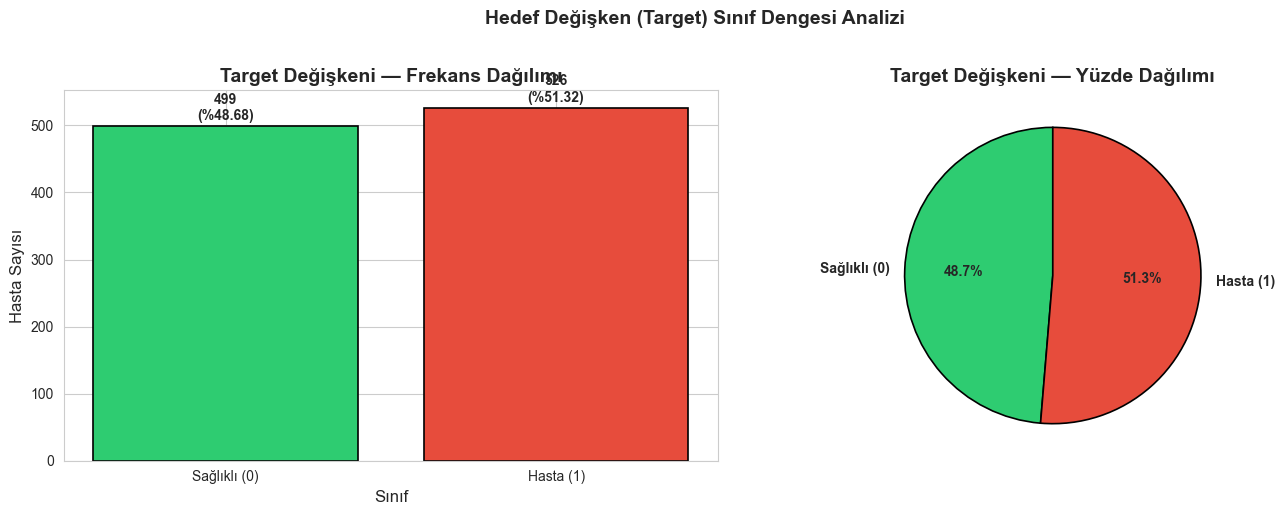

In [6]:
# ============================================================
# 4. HEDEF DEĞİŞKEN DAĞILIMI (CLASS BALANCE)
# ============================================================
# Amaç: Veri setindeki "Kalp Hastalığı Var/Yok" sınıflarının
#       dağılımını görselleştirmek.
# Önemi: Sınıf dengesizliği varsa SMOTE/Class Weight gerekir.
# ============================================================

# Hesaplamalar
target_counts = df['target'].value_counts().sort_index()
target_pct = (df['target'].value_counts(normalize=True).sort_index() * 100).round(2)

print("📊 Target Sınıf Dağılımı:")
print(f"   Sağlıklı (0): {target_counts[0]:>4} satır  (%{target_pct[0]})")
print(f"   Hasta    (1): {target_counts[1]:>4} satır  (%{target_pct[1]})")

# Grafik
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Bar Chart
colors = ['#2ecc71', '#e74c3c']  # yeşil = sağlıklı, kırmızı = hasta
bars = axes[0].bar(['Sağlıklı (0)', 'Hasta (1)'], target_counts.values,
                   color=colors, edgecolor='black', linewidth=1.2)
axes[0].set_title('Target Değişkeni — Frekans Dağılımı', fontweight='bold')
axes[0].set_ylabel('Hasta Sayısı')
axes[0].set_xlabel('Sınıf')

# Bar üstüne sayı yazdır
for bar, count, pct in zip(bars, target_counts.values, target_pct.values):
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height + 5,
                 f'{count}\n(%{pct})',
                 ha='center', va='bottom', fontweight='bold')

# 2. Pie Chart
axes[1].pie(target_counts.values,
            labels=['Sağlıklı (0)', 'Hasta (1)'],
            autopct='%1.1f%%',
            colors=colors,
            startangle=90,
            wedgeprops={'edgecolor': 'black', 'linewidth': 1.2},
            textprops={'fontweight': 'bold'})
axes[1].set_title('Target Değişkeni — Yüzde Dağılımı', fontweight='bold')

plt.suptitle('Hedef Değişken (Target) Sınıf Dengesi Analizi',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()

# Grafik kaydet (rapor için)
os.makedirs('../reports/figures', exist_ok=True)
plt.savefig('../reports/figures/01_target_distribution.png',
            dpi=150, bbox_inches='tight')
print("\n✅ Grafik kaydedildi: reports/figures/01_target_distribution.png")

plt.show()

TARGET ILE KORELASYONLAR
  [NEG] oldpeak   : -0.438  [GUCLU]
  [NEG] exang     : -0.438  [GUCLU]
  [POZ] cp        : +0.435  [GUCLU]
  [POZ] thalach   : +0.423  [GUCLU]
  [NEG] ca        : -0.382  [ORTA]
  [POZ] slope     : +0.346  [ORTA]
  [NEG] thal      : -0.338  [ORTA]
  [NEG] sex       : -0.280  [ORTA]
  [NEG] age       : -0.229  [ORTA]
  [NEG] trestbps  : -0.139  [ZAYIF]
  [POZ] restecg   : +0.134  [ZAYIF]
  [NEG] chol      : -0.100  [ZAYIF]
  [NEG] fbs       : -0.041  [ZAYIF]

Grafik kaydedildi: reports/figures/02_correlation_heatmap.png


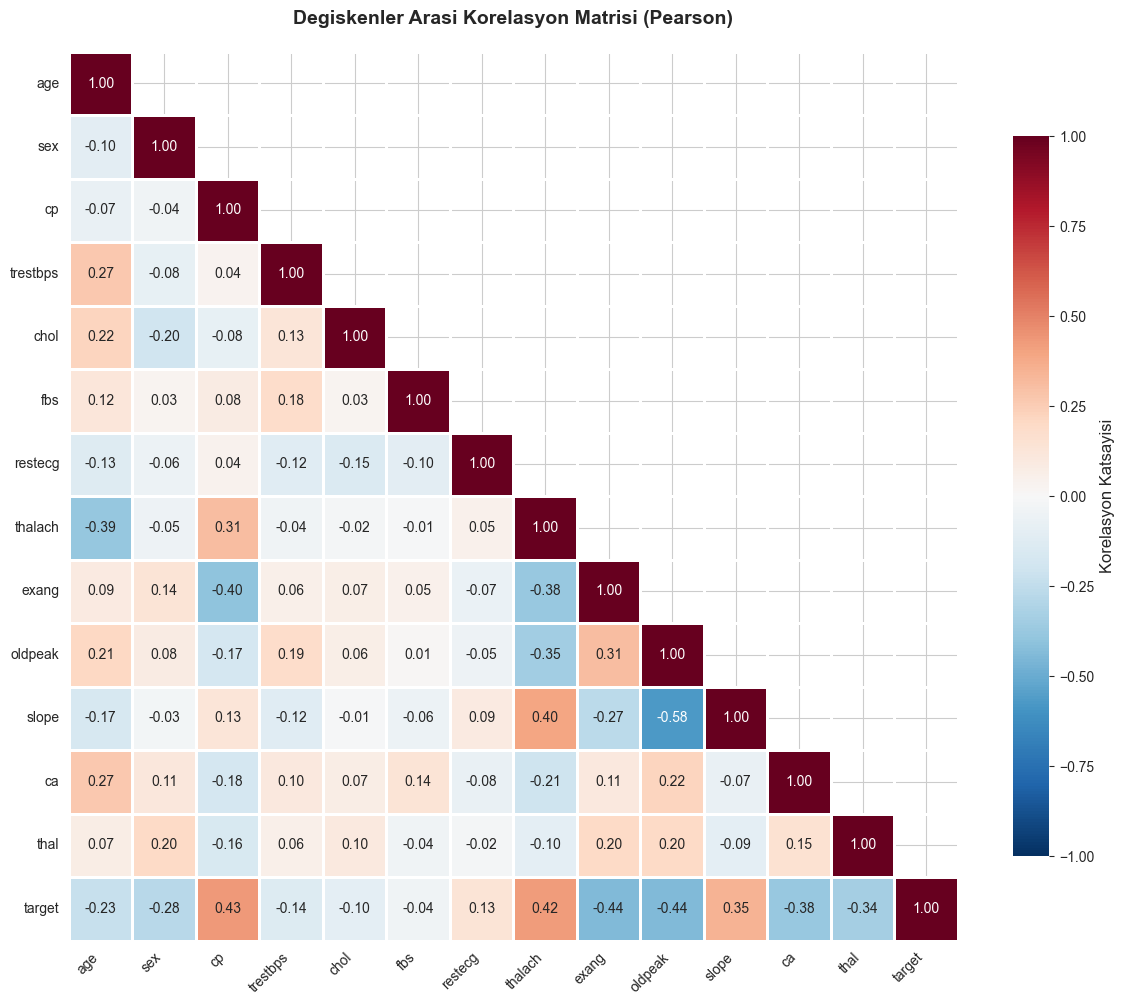

In [7]:
# ============================================================
# 5. KORELASYON MATRİSİ (HEATMAP)
# ============================================================
# Amaç: Tüm değişkenler arasındaki Pearson korelasyonlarını
#       görselleştirmek. Özellikle 'target' ile yüksek
#       korelasyonu olan değişkenleri tespit etmek.
# ============================================================

corr_matrix = df.corr()

target_corr = corr_matrix['target'].drop('target').sort_values(key=abs, ascending=False)

print("=" * 60)
print("TARGET ILE KORELASYONLAR")
print("=" * 60)
for var, corr in target_corr.items():
    arrow = "POZ" if corr > 0 else "NEG"
    if abs(corr) > 0.4:
        strength = "GUCLU"
    elif abs(corr) > 0.2:
        strength = "ORTA"
    else:
        strength = "ZAYIF"
    print(f"  [{arrow}] {var:10s}: {corr:+.3f}  [{strength}]")

plt.figure(figsize=(12, 10))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    square=True,
    linewidths=1,
    cbar_kws={'shrink': 0.8, 'label': 'Korelasyon Katsayisi'},
    vmin=-1,
    vmax=1
)

plt.title('Degiskenler Arasi Korelasyon Matrisi (Pearson)',
          fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

plt.savefig('../reports/figures/02_correlation_heatmap.png',
            dpi=150, bbox_inches='tight')
print("\nGrafik kaydedildi: reports/figures/02_correlation_heatmap.png")

plt.show()

Grafik kaydedildi: reports/figures/03_age_distribution.png

YAS ISTATISTIKLERI (HEDEFE GORE)
        count   mean   std   min   25%   50%   75%   max
target                                                  
0       499.0  56.57  7.91  35.0  52.0  58.0  62.0  77.0
1       526.0  52.41  9.63  29.0  44.0  52.0  59.0  76.0


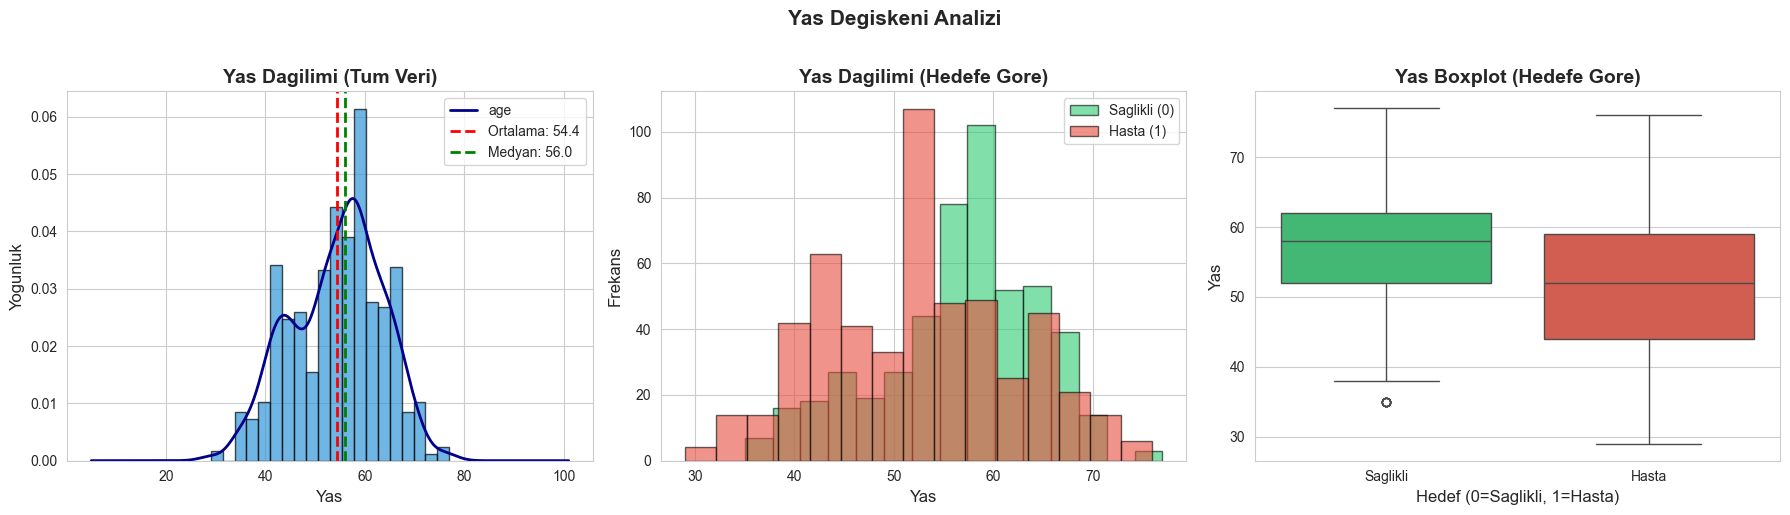

In [8]:
# ============================================================
# 6. YAS DAGILIMI (Histogram + KDE + Boxplot)
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Histogram + KDE (Genel)
axes[0].hist(df['age'], bins=20, color='#3498db', edgecolor='black',
             alpha=0.7, density=True)
df['age'].plot(kind='kde', ax=axes[0], color='darkblue', linewidth=2)
axes[0].axvline(df['age'].mean(), color='red', linestyle='--',
                linewidth=2, label=f'Ortalama: {df["age"].mean():.1f}')
axes[0].axvline(df['age'].median(), color='green', linestyle='--',
                linewidth=2, label=f'Medyan: {df["age"].median():.1f}')
axes[0].set_title('Yas Dagilimi (Tum Veri)', fontweight='bold')
axes[0].set_xlabel('Yas')
axes[0].set_ylabel('Yogunluk')
axes[0].legend()

# 2. Hedefe gore karsilastirmali histogram
axes[1].hist(df[df['target'] == 0]['age'], bins=15, alpha=0.6,
             color='#2ecc71', edgecolor='black', label='Saglikli (0)')
axes[1].hist(df[df['target'] == 1]['age'], bins=15, alpha=0.6,
             color='#e74c3c', edgecolor='black', label='Hasta (1)')
axes[1].set_title('Yas Dagilimi (Hedefe Gore)', fontweight='bold')
axes[1].set_xlabel('Yas')
axes[1].set_ylabel('Frekans')
axes[1].legend()

# 3. Boxplot (Hedefe gore) - DUZELTILMIS
sns.boxplot(data=df, x='target', y='age', hue='target',
            palette={0: '#2ecc71', 1: '#e74c3c'},
            ax=axes[2], legend=False)
axes[2].set_title('Yas Boxplot (Hedefe Gore)', fontweight='bold')
axes[2].set_xlabel('Hedef (0=Saglikli, 1=Hasta)')
axes[2].set_ylabel('Yas')
axes[2].set_xticklabels(['Saglikli', 'Hasta'])

plt.suptitle('Yas Degiskeni Analizi', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()

plt.savefig('../reports/figures/03_age_distribution.png',
            dpi=150, bbox_inches='tight')
print("Grafik kaydedildi: reports/figures/03_age_distribution.png")

# Yas istatistikleri (hedefe gore)
print("\n" + "=" * 60)
print("YAS ISTATISTIKLERI (HEDEFE GORE)")
print("=" * 60)
age_stats = df.groupby('target')['age'].describe().round(2)
print(age_stats)

plt.show()

CINSIYET VE HASTALIK CAPRAZ TABLOSU (FREKANS)
           Saglikli (0)  Hasta (1)
Kadin (0)            86        226
Erkek (1)           413        300

CINSIYET ICINDE HASTALIK ORANLARI (%)
           Saglikli (%)  Hasta (%)
Kadin (0)         27.56      72.44
Erkek (1)         57.92      42.08

Grafik kaydedildi: reports/figures/04_gender_vs_disease.png


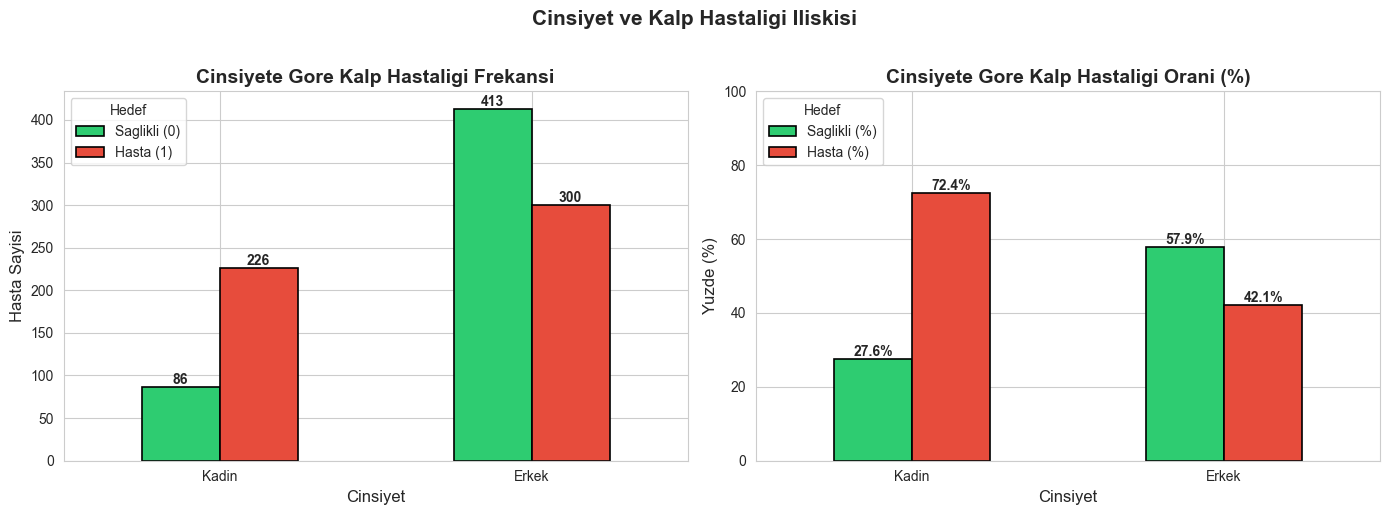

In [9]:
# ============================================================
# 7. CINSIYET VE KALP HASTALIGI ILISKISI
# ============================================================
# Amac: Cinsiyetin kalp hastalig riskine etkisini analiz etmek.
# Tip: 1 = Erkek, 0 = Kadin
# ============================================================

# Cross-tabulation (capraz tablo)
gender_target = pd.crosstab(df['sex'], df['target'],
                             rownames=['Cinsiyet'],
                             colnames=['Hedef'])
gender_target.index = ['Kadin (0)', 'Erkek (1)']
gender_target.columns = ['Saglikli (0)', 'Hasta (1)']

# Yuzde tablosu
gender_pct = pd.crosstab(df['sex'], df['target'], normalize='index') * 100
gender_pct = gender_pct.round(2)
gender_pct.index = ['Kadin (0)', 'Erkek (1)']
gender_pct.columns = ['Saglikli (%)', 'Hasta (%)']

print("=" * 60)
print("CINSIYET VE HASTALIK CAPRAZ TABLOSU (FREKANS)")
print("=" * 60)
print(gender_target)
print()
print("=" * 60)
print("CINSIYET ICINDE HASTALIK ORANLARI (%)")
print("=" * 60)
print(gender_pct)

# Grafik
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Stacked Bar Chart (Frekans)
gender_target.plot(kind='bar', stacked=False, ax=axes[0],
                   color=['#2ecc71', '#e74c3c'],
                   edgecolor='black', linewidth=1.2)
axes[0].set_title('Cinsiyete Gore Kalp Hastaligi Frekansi',
                  fontweight='bold')
axes[0].set_xlabel('Cinsiyet')
axes[0].set_ylabel('Hasta Sayisi')
axes[0].legend(title='Hedef', loc='upper left')
axes[0].set_xticklabels(['Kadin', 'Erkek'], rotation=0)

# Bar uzerine sayilari yaz
for container in axes[0].containers:
    axes[0].bar_label(container, fontsize=10, fontweight='bold')

# 2. Yuzde Bar Chart
gender_pct.plot(kind='bar', stacked=False, ax=axes[1],
                color=['#2ecc71', '#e74c3c'],
                edgecolor='black', linewidth=1.2)
axes[1].set_title('Cinsiyete Gore Kalp Hastaligi Orani (%)',
                  fontweight='bold')
axes[1].set_xlabel('Cinsiyet')
axes[1].set_ylabel('Yuzde (%)')
axes[1].legend(title='Hedef', loc='upper left')
axes[1].set_xticklabels(['Kadin', 'Erkek'], rotation=0)
axes[1].set_ylim(0, 100)

# Bar uzerine yuzdeleri yaz
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.1f%%',
                      fontsize=10, fontweight='bold')

plt.suptitle('Cinsiyet ve Kalp Hastaligi Iliskisi',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()

plt.savefig('../reports/figures/04_gender_vs_disease.png',
            dpi=150, bbox_inches='tight')
print("\nGrafik kaydedildi: reports/figures/04_gender_vs_disease.png")

plt.show()

GOGUS AGRISI TIPI VE HASTALIK FREKANSI
target    0    1
cp              
0       375  122
1        33  134
2        65  219
3        26   51

CP TIPI ICINDE HASTALIK ORANLARI (%)
target      0      1
cp                  
0       75.45  24.55
1       19.76  80.24
2       22.89  77.11
3       33.77  66.23

Grafik kaydedildi: reports/figures/05_chest_pain_analysis.png


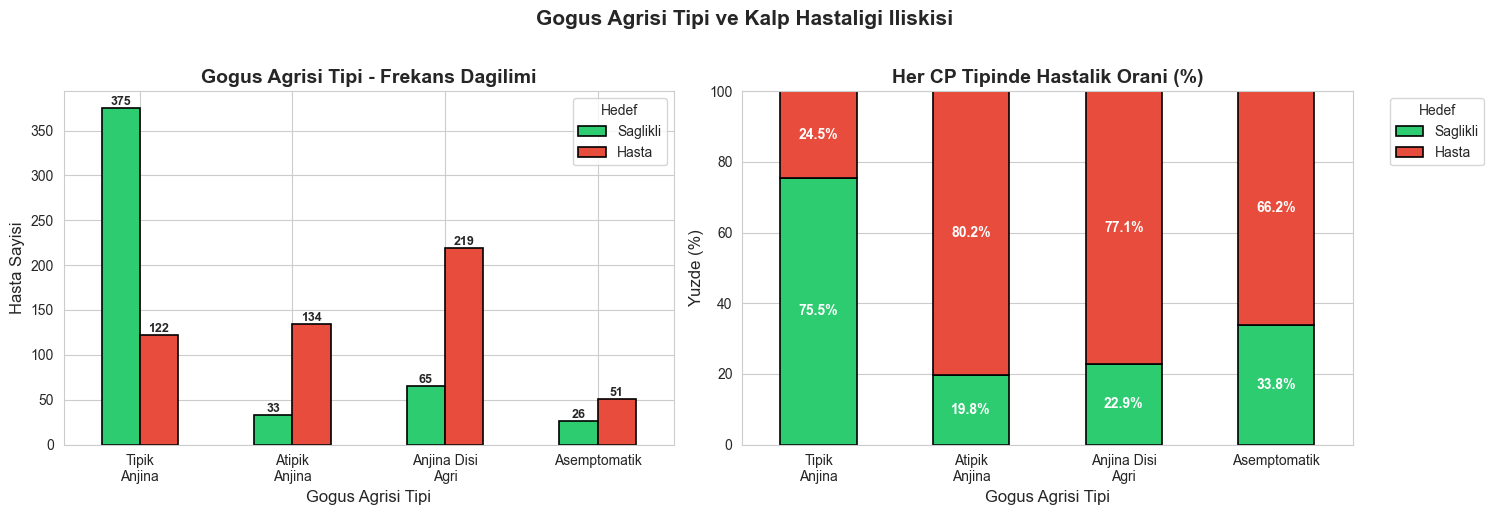

In [10]:
# ============================================================
# 8. GOGUS AGRISI TIPI (CP) ANALIZI
# ============================================================
# cp Tipi:
#   0 = Tipik anjina
#   1 = Atipik anjina
#   2 = Anjina disi agri
#   3 = Asemptomatik
# ============================================================

cp_labels = {0: 'Tipik\nAnjina', 1: 'Atipik\nAnjina',
             2: 'Anjina Disi\nAgri', 3: 'Asemptomatik'}

# Crosstab
cp_target = pd.crosstab(df['cp'], df['target'])
cp_target_pct = pd.crosstab(df['cp'], df['target'], normalize='index') * 100

print("=" * 60)
print("GOGUS AGRISI TIPI VE HASTALIK FREKANSI")
print("=" * 60)
print(cp_target)
print()
print("=" * 60)
print("CP TIPI ICINDE HASTALIK ORANLARI (%)")
print("=" * 60)
print(cp_target_pct.round(2))

# Grafik
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Frekans bar chart
cp_target.plot(kind='bar', ax=axes[0],
               color=['#2ecc71', '#e74c3c'],
               edgecolor='black', linewidth=1.2)
axes[0].set_title('Gogus Agrisi Tipi - Frekans Dagilimi',
                  fontweight='bold')
axes[0].set_xlabel('Gogus Agrisi Tipi')
axes[0].set_ylabel('Hasta Sayisi')
axes[0].set_xticklabels([cp_labels[i] for i in cp_target.index], rotation=0)
axes[0].legend(['Saglikli', 'Hasta'], title='Hedef')

for container in axes[0].containers:
    axes[0].bar_label(container, fontsize=9, fontweight='bold')

# 2. Yuzde stacked bar chart
cp_target_pct.plot(kind='bar', stacked=True, ax=axes[1],
                   color=['#2ecc71', '#e74c3c'],
                   edgecolor='black', linewidth=1.2)
axes[1].set_title('Her CP Tipinde Hastalik Orani (%)',
                  fontweight='bold')
axes[1].set_xlabel('Gogus Agrisi Tipi')
axes[1].set_ylabel('Yuzde (%)')
axes[1].set_xticklabels([cp_labels[i] for i in cp_target_pct.index], rotation=0)
axes[1].legend(['Saglikli', 'Hasta'], title='Hedef',
               bbox_to_anchor=(1.05, 1), loc='upper left')
axes[1].set_ylim(0, 100)

# Yuzde etiketleri
for i, cp_type in enumerate(cp_target_pct.index):
    healthy_pct = cp_target_pct.loc[cp_type, 0]
    sick_pct = cp_target_pct.loc[cp_type, 1]
    axes[1].text(i, healthy_pct/2, f'{healthy_pct:.1f}%',
                 ha='center', va='center', fontweight='bold', color='white')
    axes[1].text(i, healthy_pct + sick_pct/2, f'{sick_pct:.1f}%',
                 ha='center', va='center', fontweight='bold', color='white')

plt.suptitle('Gogus Agrisi Tipi ve Kalp Hastaligi Iliskisi',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()

plt.savefig('../reports/figures/05_chest_pain_analysis.png',
            dpi=150, bbox_inches='tight')
print("\nGrafik kaydedildi: reports/figures/05_chest_pain_analysis.png")

plt.show()

Grafik kaydedildi: reports/figures/06_numerical_boxplots.png

OUTLIER OZETI (IQR Yontemi)
Degisken    Outlier   Yuzde     Aralik (Min-Max)
------------------------------------------------------------
age         0         0.00      28.5 - 80.5
trestbps    30        2.93      90.0 - 170.0
chol        16        1.56      115.0 - 371.0
thalach     4         0.39      81.0 - 217.0
oldpeak     7         0.68      -2.7 - 4.5


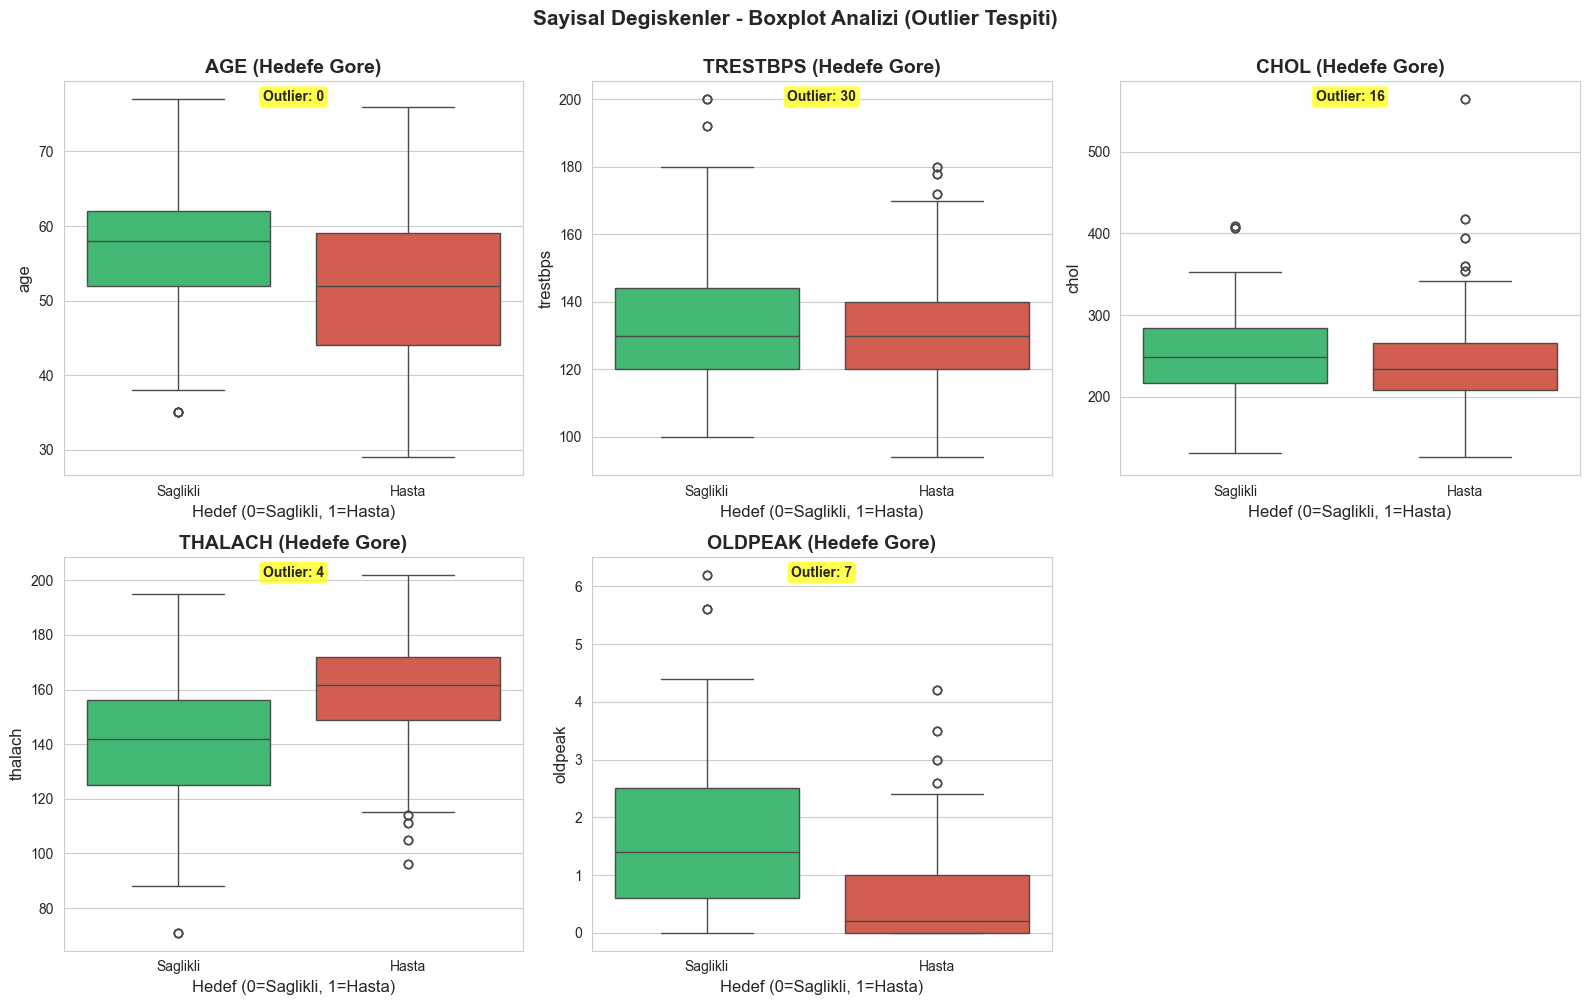

In [11]:
# ============================================================
# 9. SAYISAL DEGISKENLERIN BOXPLOT ANALIZI
# ============================================================
# Amac: Aykiri degerleri (outlier) tespit etmek.
# Hedefe gore karsilastirmali boxplotlar.
# ============================================================

# Sayisal degiskenler (sadece surekli olanlar)
numerical_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, feature in enumerate(numerical_features):
    sns.boxplot(data=df, x='target', y=feature, hue='target',
                palette={0: '#2ecc71', 1: '#e74c3c'},
                ax=axes[idx], legend=False)
    axes[idx].set_title(f'{feature.upper()} (Hedefe Gore)',
                        fontweight='bold')
    axes[idx].set_xlabel('Hedef (0=Saglikli, 1=Hasta)')
    axes[idx].set_xticklabels(['Saglikli', 'Hasta'])
    
    # Outlier sayisini hesapla ve yaz
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[feature] < lower) | (df[feature] > upper)]
    axes[idx].text(0.5, 0.95, f'Outlier: {len(outliers)}',
                   transform=axes[idx].transAxes,
                   ha='center', fontweight='bold',
                   bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))

# Son ekseni kapat (5 grafigimiz var, 6 kutuda)
axes[5].axis('off')

plt.suptitle('Sayisal Degiskenler - Boxplot Analizi (Outlier Tespiti)',
             fontsize=15, fontweight='bold', y=1.00)
plt.tight_layout()

plt.savefig('../reports/figures/06_numerical_boxplots.png',
            dpi=150, bbox_inches='tight')
print("Grafik kaydedildi: reports/figures/06_numerical_boxplots.png")

# Outlier ozeti
print("\n" + "=" * 60)
print("OUTLIER OZETI (IQR Yontemi)")
print("=" * 60)
print(f"{'Degisken':<12}{'Outlier':<10}{'Yuzde':<10}{'Aralik (Min-Max)'}")
print("-" * 60)
for feature in numerical_features:
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[feature] < lower) | (df[feature] > upper)]
    pct = len(outliers) / len(df) * 100
    print(f"{feature:<12}{len(outliers):<10}{pct:<10.2f}{lower:.1f} - {upper:.1f}")

plt.show()

Grafik kaydedildi: reports/figures/07_scatter_and_fbs.png

ACLIK KAN SEKERI (FBS) ANALIZI

fbs=0 (Normal kan sekeri):
   Saglikli: %47.82
   Hasta:    %52.18

fbs=1 (Yuksek kan sekeri):
   Saglikli: %53.59
   Hasta:    %46.41

YORUM:


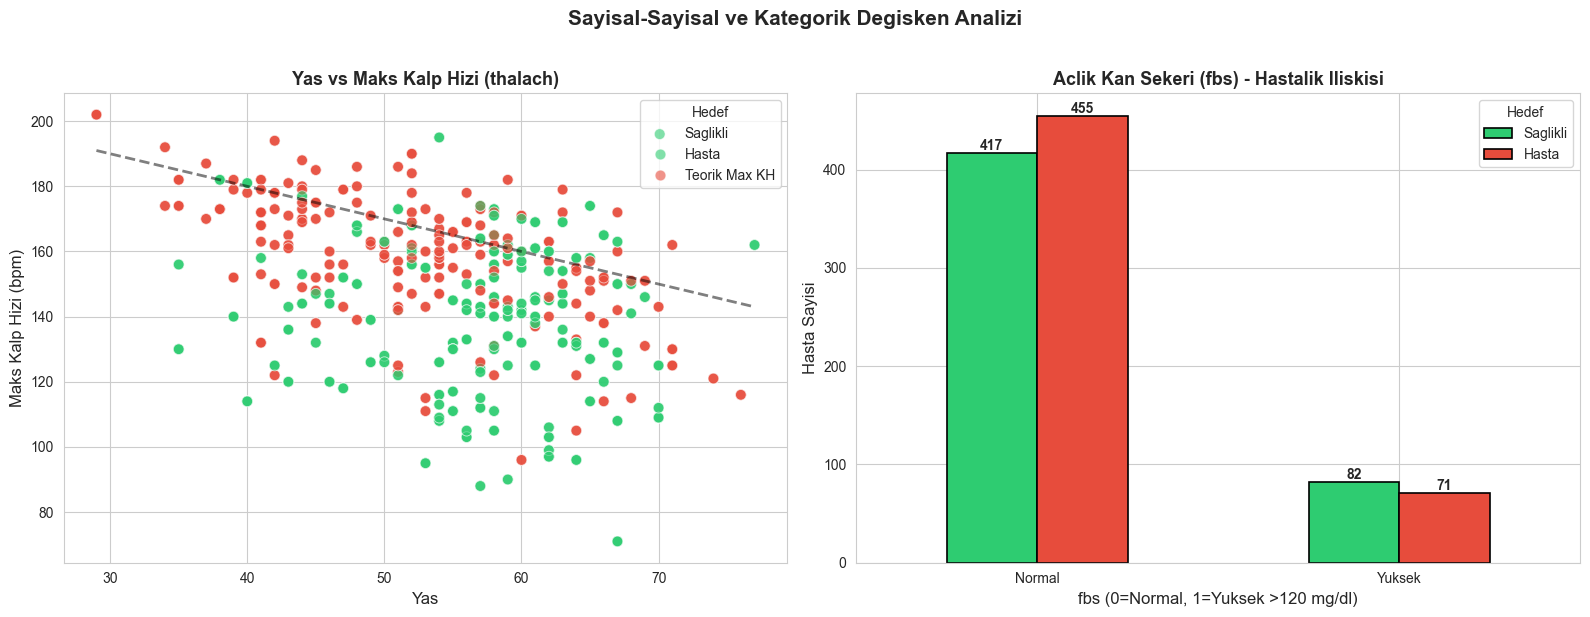

In [12]:
# ============================================================
# 10. SCATTER PLOT: YAS vs MAX KALP HIZI (THALACH)
# ============================================================
# Bu iki degiskenin kombinasyonu modelimiz icin guclu sinyaldir.
# Tibbi formul: 220 - yas = teorik max kalp hizi
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Scatter plot
sns.scatterplot(data=df, x='age', y='thalach', hue='target',
                palette={0: '#2ecc71', 1: '#e74c3c'},
                alpha=0.6, s=60, ax=axes[0])

# Tibbi formul cizgisi: y = 220 - x
ages_line = np.linspace(df['age'].min(), df['age'].max(), 100)
max_hr_theoretical = 220 - ages_line
axes[0].plot(ages_line, max_hr_theoretical, 'k--', linewidth=2,
             alpha=0.5, label='Teorik Max KH (220-yas)')

axes[0].set_title('Yas vs Maks Kalp Hizi (thalach)',
                  fontweight='bold', fontsize=13)
axes[0].set_xlabel('Yas')
axes[0].set_ylabel('Maks Kalp Hizi (bpm)')
axes[0].legend(title='Hedef', labels=['Saglikli', 'Hasta', 'Teorik Max KH'])

# 2. Aclik Kan Sekeri (fbs) - dusuk korelasyonlu
fbs_target = pd.crosstab(df['fbs'], df['target'])
fbs_target.plot(kind='bar', ax=axes[1],
                color=['#2ecc71', '#e74c3c'],
                edgecolor='black', linewidth=1.2)
axes[1].set_title('Aclik Kan Sekeri (fbs) - Hastalik Iliskisi',
                  fontweight='bold', fontsize=13)
axes[1].set_xlabel('fbs (0=Normal, 1=Yuksek >120 mg/dl)')
axes[1].set_ylabel('Hasta Sayisi')
axes[1].legend(['Saglikli', 'Hasta'], title='Hedef')
axes[1].set_xticklabels(['Normal', 'Yuksek'], rotation=0)

for container in axes[1].containers:
    axes[1].bar_label(container, fontsize=10, fontweight='bold')

plt.suptitle('Sayisal-Sayisal ve Kategorik Degisken Analizi',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()

plt.savefig('../reports/figures/07_scatter_and_fbs.png',
            dpi=150, bbox_inches='tight')
print("Grafik kaydedildi: reports/figures/07_scatter_and_fbs.png")

# fbs analizi
print("\n" + "=" * 60)
print("ACLIK KAN SEKERI (FBS) ANALIZI")
print("=" * 60)
fbs_pct = pd.crosstab(df['fbs'], df['target'], normalize='index') * 100
print(f"\nfbs=0 (Normal kan sekeri):")
print(f"   Saglikli: %{fbs_pct.loc[0, 0]:.2f}")
print(f"   Hasta:    %{fbs_pct.loc[0, 1]:.2f}")
print(f"\nfbs=1 (Yuksek kan sekeri):")
print(f"   Saglikli: %{fbs_pct.loc[1, 0]:.2f}")
print(f"   Hasta:    %{fbs_pct.loc[1, 1]:.2f}")

print("\nYORUM:")
diff = abs(fbs_pct.loc[0, 1] - fbs_pct.loc[1, 1])
if diff < 5:
    print(f"-> Iki grupta hastalik orani benzer (fark: %{diff:.2f})")
    print("-> fbs degiskeni hastaligi belirlemede ZAYIF bir gostergedir")
    print("-> Bu, korelasyon analizini desteklemektedir (r = -0.04)")

plt.show()